# Flight Ticket Price Analysis
### Identifying Key Factors That Influence Indian Domestic Airfare

## Objective
Analyze flight ticket prices and identify the factors influencing airfare such as:

- Airline
- Route
- Duration
- Number of Stops
- Source & Destination

## Business Questions

1. Which airlines are most expensive?
2. How do stops affect pricing?
3. Does flight duration impact ticket cost?
4. Which routes generate premium pricing?
5. Which cities have highest average fares?

## Data Loading & Overview


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("flight_dataset.csv")
df = data.copy()


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Airline       2000 non-null   str    
 1   Dep_Time      2000 non-null   str    
 2   Source        2000 non-null   str    
 3   Destination   2000 non-null   str    
 4   Route         2000 non-null   str    
 5   Arrival_Time  2000 non-null   str    
 6   Duration      1939 non-null   str    
 7   Total_Stops   1638 non-null   str    
 8   Price         1893 non-null   float64
dtypes: float64(1), str(8)
memory usage: 140.8 KB


In [4]:
df.head()

,Airline,Dep_Time,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Price
0,GoAir,12:00 AM,Delhi,Chennai,Delhi → Delhi → Chennai,12:00 AM,152 min,2 stops,24318.0
1,AirAsia,12:00 AM,Delhi,Chennai,Delhi → Chennai,12:00 AM,2h 17m,non-stop,8158.0
2,SpiceJet,12:00 AM,Chennai,Kolkata,Chennai → Kolkata → Kolkata,12-00 AM,2h 51m,2 stops,24106.0
3,Air India,12:00 AM,Kolkata,Delhi,Kolkata → Delhi → Delhi,12:00 AM,7h 27m,1 stop,3140.0
4,AirAsia,12:00 AM,Mumbai,Bangalore,Mumbai → Bangalore,00:00,3h 35m,1 stop,21752.0


In [5]:
df.sample()

,Airline,Dep_Time,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Price
1349,GoAir,12:00 AM,Bangalore,Mumbai,Bangalore → Mumbai,12:00 AM,10h 12m,one stop,9510.0


In [6]:
print(df.describe())

              Price
count   1893.000000
mean   13513.452721
std     6666.453055
min     2003.000000
25%     7804.000000
50%    13484.000000
75%    19206.000000
max    24988.000000


In [7]:
print(df.columns)

Index(['Airline', 'Dep_Time', 'Source', 'Destination', 'Route', 'Arrival_Time',
       'Duration', 'Total_Stops', 'Price'],
      dtype='str')


In [8]:
print("Rows, Columns :", df.shape)

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Rows, Columns : (2000, 9)

Duplicate Rows:
0

Missing Values:
Airline           0
Dep_Time          0
Source            0
Destination       0
Route             0
Arrival_Time      0
Duration         61
Total_Stops     362
Price           107
dtype: int64

Data Types:
Airline             str
Dep_Time            str
Source              str
Destination         str
Route               str
Arrival_Time        str
Duration            str
Total_Stops         str
Price           float64
dtype: object


In [51]:
summary = pd.DataFrame({
    "dtype":         df.dtypes,
    "missing_count": df.isnull().sum(),
    "missing_%":     (df.isnull().sum() / len(df) * 100).round(2),
    "unique_values": df.nunique(),
})
summary

,dtype,missing_count,missing_%,unique_values
airline,str,0,0.0,6
source,str,0,0.0,6
destination,str,0,0.0,6
route,str,0,0.0,208
total_stops,int64,0,0.0,2
duration,float64,0,0.0,567
price,float64,0,0.0,1759
price_per_hour,float64,0,0.0,1836


In [10]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts().head())


Airline
Airline
Vistara      363
SpiceJet     345
Air India    333
Indigo       330
GoAir        316
Name: count, dtype: int64

Dep_Time
Dep_Time
12:00 AM     982
00:00        917
00:00         52
12:00 AM      49
Name: count, dtype: int64

Source
Source
Bangalore    362
Hyderabad    348
Mumbai       329
Chennai      327
Delhi        322
Name: count, dtype: int64

Destination
Destination
Bangalore    350
Kolkata      344
Delhi        342
Hyderabad    334
Chennai      318
Name: count, dtype: int64

Route
Route
Hyderabad → Bangalore    53
Bangalore → Delhi        52
Bangalore → Kolkata      41
Delhi → Hyderabad        39
Hyderabad → Mumbai       38
Name: count, dtype: int64

Arrival_Time
Arrival_Time
12:00 AM    982
00:00       914
12-00 AM     55
00-00        49
Name: count, dtype: int64

Duration
Duration
2h 11m    8
8h 52m    7
8h 3m     7
6h 29m    7
3h 50m    7
Name: count, dtype: int64

Total_Stops
Total_Stops
non-stop    350
one stop    334
2 stops     324
3 stops     318
1 stop 

C:\Users\AYUSH\AppData\Local\Temp\ipykernel_11312\158628429.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


## Data Cleaning Summary

The following preprocessing steps were performed to improve data quality:

- Handled missing values in duration and price columns.
- Removed records containing missing target values.
- Converted flight duration into a numeric format for analysis.
- Validated the Total Stops column against route information.
- Reconstructed stop counts from route data to resolve inconsistencies.
- Checked and confirmed the absence of duplicate records.
- Standardized column arrangement and formatting.

In [11]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns)

Index(['airline', 'dep_time', 'source', 'destination', 'route', 'arrival_time',
       'duration', 'total_stops', 'price'],
      dtype='str')


In [12]:
stops_map = {
    "non-stop": 0,
    "1 stop":   1,
    "one stop": 1,
    "2 stops":  2,
    "3 stops":  3,
}
df["total_stops"] = df["total_stops"].replace(stops_map).fillna(0).astype(int)
print(df["total_stops"].value_counts().sort_index())

total_stops
0    712
1    646
2    324
3    318
Name: count, dtype: int64


In [ ]:
# Convert duration string → total hours (e.g. "2h 30m" → 2.5)
df["duration"] = (
    pd.to_timedelta(df["duration"]).dt.total_seconds() / 3600
).round(2)

0      0 days 02:32:00
1      0 days 02:17:00
2      0 days 02:51:00
3      0 days 07:27:00
4      0 days 03:35:00
             ...      
1995   0 days 09:21:00
1996   0 days 03:03:00
1997   0 days 04:23:00
1998   0 days 08:50:00
1999   0 days 06:40:00
Name: duration, Length: 2000, dtype: timedelta64[us]


In [ ]:
df["price_per_hour"] = (
    df["price"] / df["duration"]
)

In [18]:
print(df.isnull().sum()/len(df)*100)

airline           0.00
dep_time          0.00
source            0.00
destination       0.00
route             0.00
arrival_time      0.00
duration          3.05
total_stops       0.00
price             5.35
price_per_hour    8.20
dtype: float64


In [19]:
df[df["duration"].isnull()]

,airline,dep_time,source,destination,route,arrival_time,duration,total_stops,price,price_per_hour
93,Vistara,00:00,Delhi,Chennai,Delhi → Chennai,12:00 AM,NaN,0,3341.0,NaN
101,Indigo,12:00 AM,Hyderabad,Kolkata,Hyderabad → Delhi → Kolkata,12:00 AM,NaN,0,NaN,NaN
233,GoAir,12:00 AM,Delhi,Hyderabad,Delhi → Delhi → Hyderabad,00:00,NaN,1,14116.0,NaN
235,Air India,00:00,Bangalore,Kolkata,Bangalore → Kolkata,12:00 AM,NaN,2,7639.0,NaN
247,Vistara,00:00,Delhi,Chennai,Delhi → Chennai,00-00,NaN,3,21857.0,NaN
...,...,...,...,...,...,...,...,...,...,...
1920,Vistara,12:00 AM,Bangalore,Kolkata,Bangalore → Kolkata,12:00 AM,NaN,3,6182.0,NaN
1936,Vistara,12:00 AM,Kolkata,Hyderabad,Kolkata → Hyderabad,00:00,NaN,2,17774.0,NaN
1949,GoAir,00:00,Mumbai,Delhi,Mumbai → Hyderabad → Delhi,12:00 AM,NaN,0,19228.0,NaN
1971,AirAsia,12:00 AM,Mumbai,Bangalore,Mumbai → Hyderabad → Bangalore,00:00,NaN,1,21881.0,NaN


In [20]:
df[df["price"].isnull()]

,airline,dep_time,source,destination,route,arrival_time,duration,total_stops,price,price_per_hour
17,Indigo,12:00 AM,Hyderabad,Mumbai,Hyderabad → Mumbai,00:00,9.70,0,NaN,NaN
50,AirAsia,00:00,Kolkata,Mumbai,Kolkata → Hyderabad → Mumbai,12:00 AM,1.60,3,NaN,NaN
91,Air India,12:00 AM,Chennai,Mumbai,Chennai → Mumbai,00:00,1.67,0,NaN,NaN
94,SpiceJet,12:00 AM,Mumbai,Hyderabad,Mumbai → Hyderabad,00:00,5.38,0,NaN,NaN
101,Indigo,12:00 AM,Hyderabad,Kolkata,Hyderabad → Delhi → Kolkata,12:00 AM,NaN,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1876,Indigo,12:00 AM,Hyderabad,Kolkata,Hyderabad → Kolkata,00:00,7.40,2,NaN,NaN
1905,Air India,00:00,Mumbai,Bangalore,Mumbai → Chennai → Bangalore,12:00 AM,4.40,2,NaN,NaN
1913,Indigo,12:00 AM,Chennai,Kolkata,Chennai → Delhi → Kolkata,00:00,8.90,1,NaN,NaN
1933,Vistara,12:00 AM,Bangalore,Chennai,Bangalore → Chennai,12-00 AM,2.87,1,NaN,NaN


In [21]:
df.dropna(subset=["duration","price"],inplace=True)

### Data Validation

Validate whether the reported number of stops matches the actual route structure.

In [22]:
df["route_stops"] = df["route"].str.count("→")-1

In [23]:
mismatch = df[df["total_stops"] != df["route_stops"]]

print(f"Mismatch records: {len(mismatch)/len(df)*100}%")

Mismatch records: 65.0326797385621%


In [24]:
df.drop(columns=["total_stops"], inplace=True)

In [25]:
df.rename(columns={"route_stops":"total_stops"},inplace=True)

In [26]:
df = df[
    [
        "airline",
        "source",
        "destination",
        "route",
        "total_stops",
        "dep_time",
        "arrival_time",
        "duration",
        "price",
        "price_per_hour"
    ]
]

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df["dep_time"].value_counts()

dep_time
12:00 AM     898
00:00        846
12:00 AM      46
00:00         46
Name: count, dtype: int64

In [29]:
df["arrival_time"].value_counts()

arrival_time
12:00 AM    900
00:00       838
12-00 AM     53
00-00        45
Name: count, dtype: int64

In [30]:
df.drop(columns=["dep_time","arrival_time"], inplace=True)

## Exploratory Data Analysis

The cleaned dataset was analyzed to identify pricing patterns, route trends, airline performance, and travel behavior.

The following visualizations highlight the key findings obtained from the analysis.

In [31]:
df.groupby("airline").agg({
    "price":["mean","median","min","max","count"]
})

price                                
                   mean   median     min      max count
airline                                                
Air India  12732.794020  12197.0  2061.0  24984.0   301
AirAsia    13340.632867  13439.0  2013.0  24867.0   286
GoAir      13217.520408  13032.0  2024.0  24988.0   294
Indigo     13500.036789  13489.0  2003.0  24942.0   299
SpiceJet   13879.099071  14320.0  2056.0  24943.0   323
Vistara    14337.027027  14805.0  2097.0  24930.0   333

In [32]:
top_expensive_routes = df.groupby("route")["price"].agg(["count","mean","median"]).sort_values(by="mean",ascending=False).head(10)
top_expensive_routes

,count,mean,median
route,,,
Hyderabad → Delhi → Kolkata,1,24645.000000,24645.0
Hyderabad → Chennai → Chennai,2,21988.500000,21988.5
Bangalore → Delhi → Hyderabad,3,21430.666667,20005.0
Kolkata → Bangalore → Chennai,3,20965.666667,20569.0
Bangalore → Hyderabad → Mumbai,2,20666.500000,20666.5
Chennai → Kolkata → Bangalore,3,19725.000000,19841.0
Kolkata → Kolkata → Delhi,2,19156.000000,19156.0
Delhi → Chennai → Bangalore,7,19103.000000,18922.0
Mumbai → Delhi → Kolkata,7,18908.000000,17829.0


In [33]:
source = df.groupby("source")["price"].agg(["count","mean","median"]).sort_values(by="mean",ascending=False)
source

,count,mean,median
source,,,
Mumbai,302,14240.728477,14535.5
Delhi,296,13682.905405,13432.5
Chennai,299,13663.742475,13632.0
Hyderabad,321,13410.950156,13337.0
Kolkata,283,13305.159011,12829.0
Bangalore,335,12898.683582,12590.0


In [34]:
destination = df.groupby("destination")["price"].agg(["count","mean","median"]).sort_values(by="mean",ascending=False)
destination

,count,mean,median
destination,,,
Delhi,316,14011.231013,13920.5
Kolkata,314,13947.767516,14511.0
Bangalore,329,13685.914894,13439.0
Mumbai,289,13281.986159,13417.0
Chennai,283,13075.901060,12348.0
Hyderabad,305,13045.393443,13065.0


In [35]:
stops = df.groupby("total_stops")["price"].agg(["count","mean","median"]).sort_values(by="mean",ascending=False)
stops

,count,mean,median
total_stops,,,
1,932,13782.635193,13803.0
0,904,13254.664823,13035.0


In [36]:
airline = df.groupby("airline")["price"].agg(["count","mean","median"]).sort_values(by="mean",ascending=False)
airline

,count,mean,median
airline,,,
Vistara,333,14337.027027,14805.0
SpiceJet,323,13879.099071,14320.0
Indigo,299,13500.036789,13489.0
AirAsia,286,13340.632867,13439.0
GoAir,294,13217.520408,13032.0
Air India,301,12732.794020,12197.0


In [37]:
top_routes = df.groupby("airline")["route"].value_counts().sort_values(ascending=False).head()
top_routes

airline   route                
Vistara   Hyderabad → Bangalore    14
SpiceJet  Bangalore → Delhi        12
Indigo    Hyderabad → Kolkata      10
Vistara   Bangalore → Delhi         9
SpiceJet  Bangalore → Hyderabad     9
Name: count, dtype: int64

In [38]:
airline_stops = df.groupby(["airline", "total_stops"])["price"].mean().unstack()
airline_stops.round(0)

total_stops,0,1
airline,,
Air India,12505.0,12954.0
AirAsia,13265.0,13411.0
GoAir,13085.0,13346.0
Indigo,13478.0,13521.0
SpiceJet,13326.0,14415.0
Vistara,13790.0,14893.0


In [39]:
# price by hour
route_efficiency = (
    df.groupby("route")
    .agg(avg_price=("price", "mean"), avg_duration=("duration", "mean"), count=("price", "count"))
    .query("count >= 10") 
    .assign(price_per_hour=lambda x: x["avg_price"] / x["avg_duration"])
    .sort_values("price_per_hour", ascending=False)
    .head(10)
    .round(2)
)
route_efficiency

,avg_price,avg_duration,count,price_per_hour
route,,,,
Mumbai → Delhi,17361.63,5.96,19,2914.05
Kolkata → Delhi,15339.83,5.41,29,2836.90
Delhi → Bangalore,16296.50,5.88,26,2773.69
Hyderabad → Bangalore,13132.06,4.86,50,2701.85
Mumbai → Kolkata,15409.93,5.73,29,2690.80
Hyderabad → Mumbai,12845.31,4.83,32,2661.38
Chennai → Delhi,12457.20,4.68,25,2661.11
Delhi → Chennai → Hyderabad,16694.30,6.59,10,2533.66
Bangalore → Delhi,13804.02,5.57,48,2476.98


In [40]:
# popular source count
popular_source = (
    df.groupby(["airline", "source"])
    .size()
    .reset_index(name="count")
    .sort_values(["airline", "count"], ascending=[True, False])
    .groupby("airline")
    .first()
)
popular_source

,source,count
airline,,
Air India,Bangalore,64
AirAsia,Bangalore,55
GoAir,Delhi,57
Indigo,Hyderabad,59
SpiceJet,Bangalore,69
Vistara,Mumbai,64


In [ ]:
# Stop distribution share per airline (%)
stop_share = (
    df.groupby(["airline", "total_stops"])
    .size()
    .groupby(level=0)
    .apply(lambda x: (x / x.sum() * 100).round(1))
    .unstack(fill_value=0)
)
stop_share

,total_stops,0,1
airline,airline,,
Air India,Air India,49.2,50.8
AirAsia,AirAsia,47.9,52.1
GoAir,GoAir,49.3,50.7
Indigo,Indigo,49.2,50.8
SpiceJet,SpiceJet,49.2,50.8
Vistara,Vistara,50.5,49.5


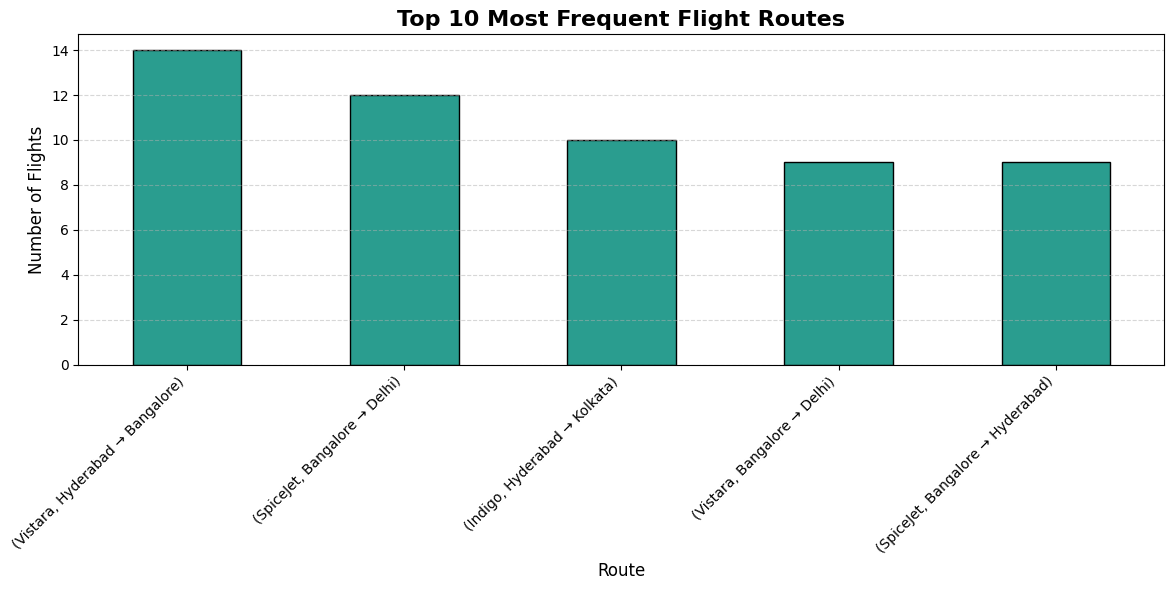

In [55]:
# Top 10 Most Frequent Flight Routes

plt.figure(figsize=(12,6))

top_routes.plot(
    kind="bar",
    color="#2A9D8F",
    edgecolor="black"
)

plt.title(
    "Top 10 Most Frequent Flight Routes",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Route", fontsize=12)
plt.ylabel("Number of Flights", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

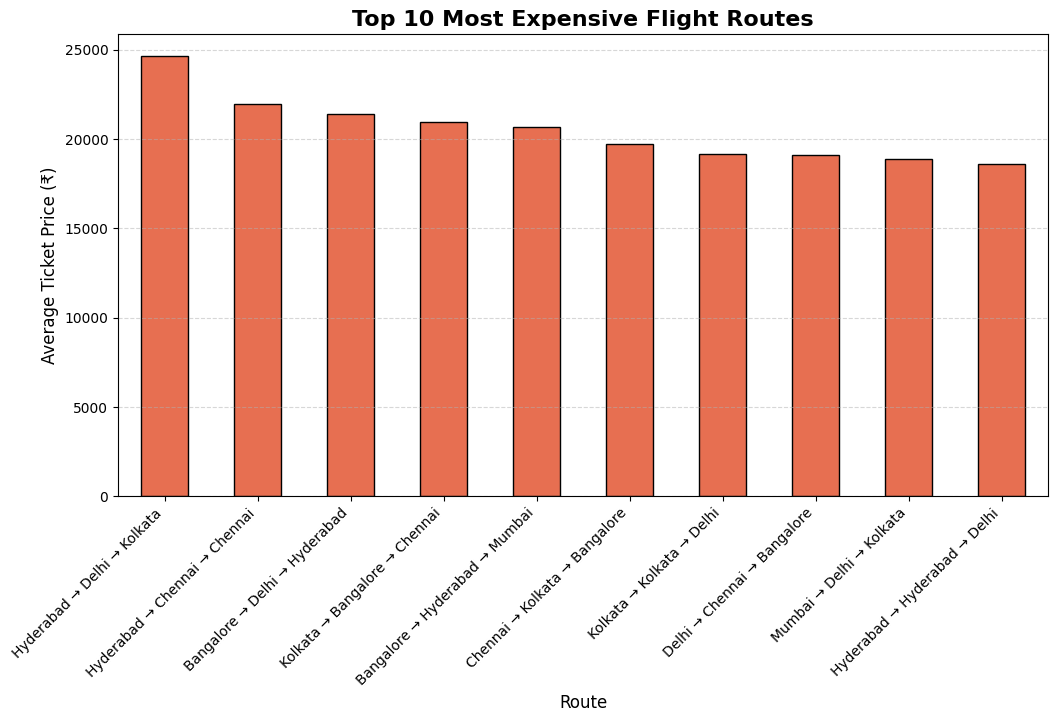

In [43]:
# Top 10 Most Expensive Flight Routes

plt.figure(figsize=(12,6))

top_expensive_routes["mean"].plot(
    kind="bar",
    color="#E76F51",
    edgecolor="black"
)

plt.title(
    "Top 10 Most Expensive Flight Routes",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Route", fontsize=12)
plt.ylabel("Average Ticket Price (₹)", fontsize=12)

plt.xticks(rotation=45, ha="right")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.show()

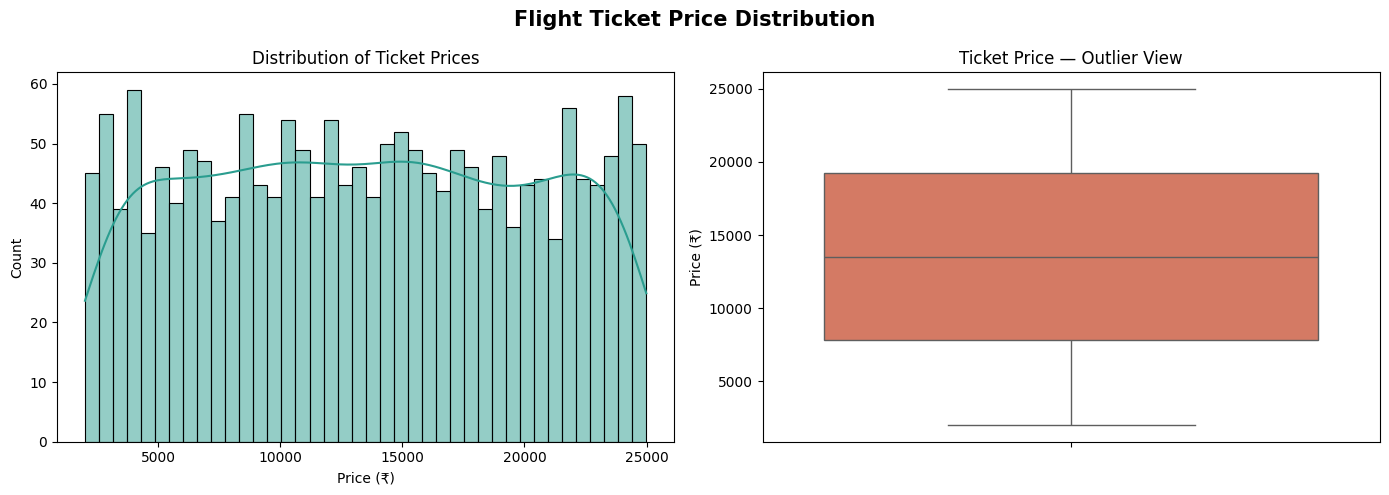

Median: ₹13,486  |  Mean: ₹13,523  |  Std: ₹6,679


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(df["price"], bins=40, kde=True, color="#2A9D8F", ax=axes[0])
axes[0].set_title("Distribution of Ticket Prices")
axes[0].set_xlabel("Price (₹)")
axes[0].set_ylabel("Count")

# Box plot — surfaces outliers
sns.boxplot(y=df["price"], color="#E76F51", ax=axes[1])
axes[1].set_title("Ticket Price — Outlier View")
axes[1].set_ylabel("Price (₹)")

plt.suptitle("Flight Ticket Price Distribution", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Median: ₹{df['price'].median():,.0f}  |  Mean: ₹{df['price'].mean():,.0f}  |  Std: ₹{df['price'].std():,.0f}")

C:\Users\AYUSH\AppData\Local\Temp\ipykernel_11312\1810177660.py:2: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.scatterplot(


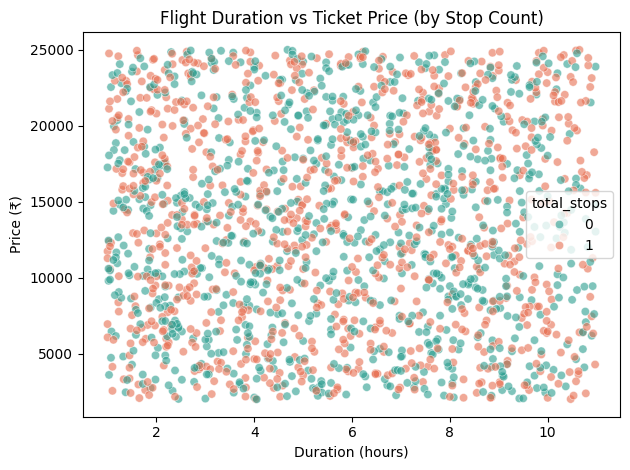

In [50]:
# Flight Duration vs Ticket Price
sns.scatterplot(
    data=df, x="duration", y="price",
    hue="total_stops", palette=["#2A9D8F","#E76F51","#457B9D"],
    alpha=0.6
)
plt.title("Flight Duration vs Ticket Price (by Stop Count)")
plt.xlabel("Duration (hours)")
plt.ylabel("Price (₹)")
plt.tight_layout()
plt.show()

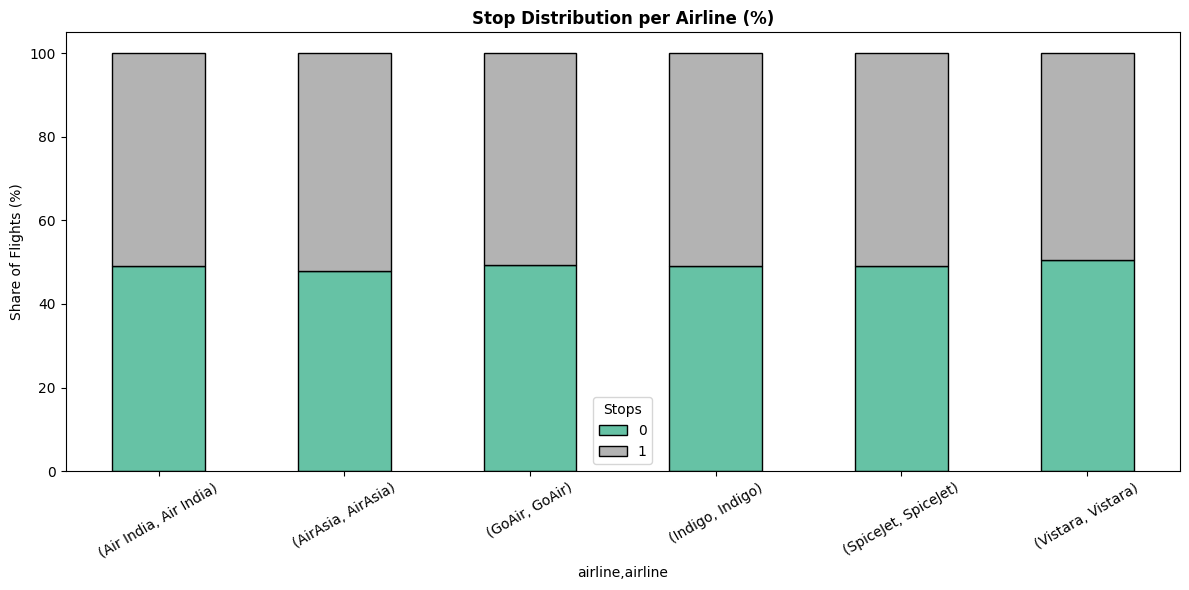

In [ ]:
# stop share per airline distribution

stop_share.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="Set2", edgecolor="black")
plt.title("Stop Distribution per Airline (%)", fontweight="bold")
plt.ylabel("Share of Flights (%)")
plt.xticks(rotation=30)
plt.legend(title="Stops")
plt.tight_layout()
plt.show()

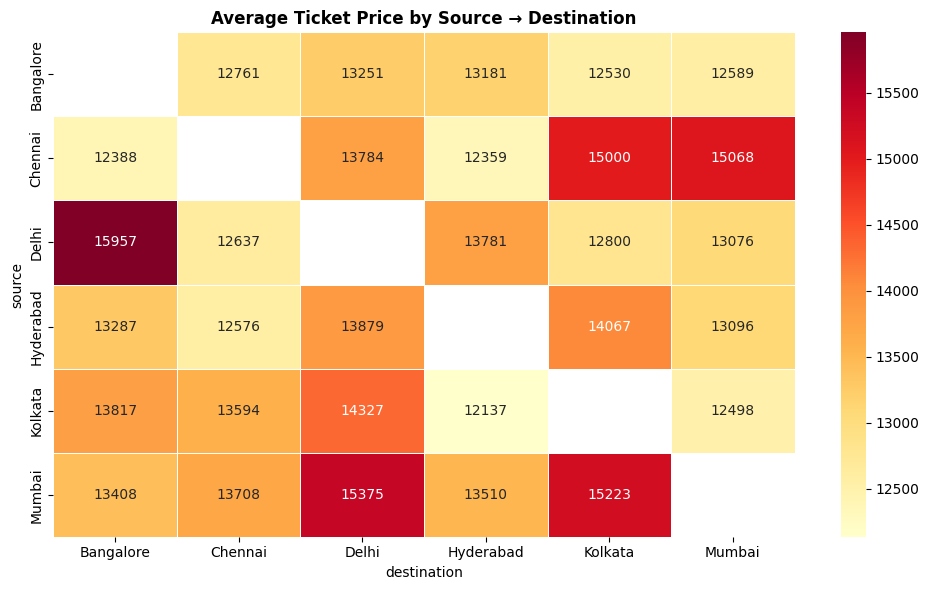

In [47]:
pivot = df.pivot_table(index="source", columns="destination", values="price", aggfunc="mean")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5)
plt.title("Average Ticket Price by Source → Destination", fontweight="bold")
plt.tight_layout()
plt.show()

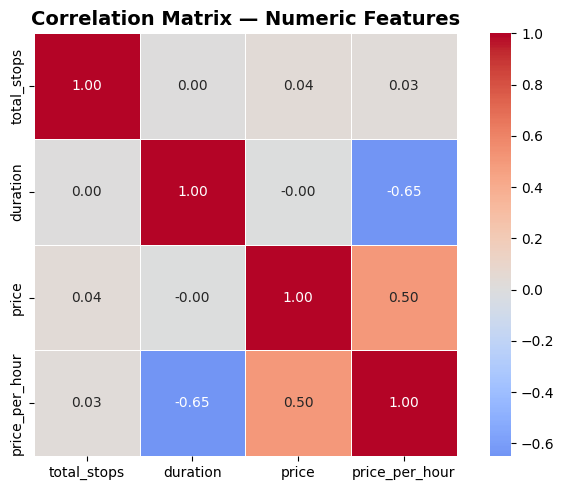

In [48]:
corr = df[["total_stops", "duration", "price", "price_per_hour"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)
plt.title("Correlation Matrix — Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Key Insights

1. Vistara is the most expensive airline at a median of ₹14,805, but the gap between
airlines is smaller than expected — Air India at the bottom is only ₹2,600 cheaper.
Airline brand alone isn't driving big price differences here.

2. One thing that surprised me: one-stop flights (₹13,803) cost more on average than
direct flights (₹13,035). I expected the opposite. This suggests the routes that
happen to have stopovers are just inherently pricier, not the stops themselves.

3. Price varies a lot — std dev of ₹6,679 on a median of ₹13,486. That spread isn't
coming from airlines, it's coming from specific routes commanding premium fares.

4. Flight duration has almost zero correlation with price (-0.002). A 5-hour flight
isn't meaningfully more expensive than a 2-hour one. Route matters far more than
how long you're in the air.

5. During cleaning, I found the original `total_stops` column had significant mismatches
with the actual route data — so I re-derived stop counts from the route string and
replaced it before running any analysis.

## Conclusion

Going in, I expected airline brand to be the biggest price driver. It isn't —
route is. A Vistara ticket on a cheap route will still be cheaper than an IndiGo
ticket on an expensive one.

The most useful thing I did in this project wasn't a chart — it was catching that
the `total_stops` column was inconsistent with the actual route data and fixing it
before the analysis. Bad stop data would have quietly corrupted every stops-related
finding.

The near-zero duration-price correlation (-0.002) was the most surprising result.
I'd assumed longer flights cost more. They don't — at least not in this dataset.

Next step is modelling — the dataset is clean, the key features are identified,
and route + airline encoding should give a regression model something real to work with.